# Defer-or-Not-Defer Classification
## TF Baselines → DistilBERT Transfer Learning

Binary classification of defer decisions from text data.

Models:
- Shallow Neural Network
- BiLSTM
- DistilBERT (Frozen Encoder)
- DistilBERT (Partial Fine-tuning)

Metrics:
- ROC-AUC
- PR-AUC
- Precision / Recall / F1

In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

from pathlib import Path
import json
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score
)
import matplotlib.pyplot as plt


DATASET_DIR = Path("../data").resolve()
print("DATASET_DIR:", DATASET_DIR)

# 3) load CSV splits
df_full  = pd.read_csv(DATASET_DIR / "neurodevdiff_v1_full.csv")
df_train = pd.read_csv(DATASET_DIR / "neurodevdiff_v1_train.csv")
df_val   = pd.read_csv(DATASET_DIR / "neurodevdiff_v1_val.csv")
df_test  = pd.read_csv(DATASET_DIR / "neurodevdiff_v1_test.csv")

print("\nShapes:")
print("full :", df_full.shape)
print("train:", df_train.shape)
print("val  :", df_val.shape)
print("test :", df_test.shape)

# 4) load JSONL splits (LLM play pairs)
train_jsonl = pd.read_json(DATASET_DIR / "neurodevdiff_v1_train.jsonl", lines=True)
val_jsonl   = pd.read_json(DATASET_DIR / "neurodevdiff_v1_val.jsonl", lines=True)
test_jsonl  = pd.read_json(DATASET_DIR / "neurodevdiff_v1_test.jsonl", lines=True)

print("\nJSONL shapes:")
print("train_jsonl:", train_jsonl.shape)
print("val_jsonl  :", val_jsonl.shape)
print("test_jsonl :", test_jsonl.shape)

# 5) metadata
with open(DATASET_DIR / "neurodevdiff_v1_metadata.json", "r", encoding="utf-8") as f:
    meta = json.load(f)

print("\nMetadata keys:", list(meta.keys()))
print("Class balance:", meta.get("class_balance"))



def jsonl_to_xy(df_jsonl: pd.DataFrame):
    """
    Input: dataframe con colonne [input, output, meta]
    Output:
      X: array di testi (stringhe) -> quello che daremo al modello
      y: array di 0/1             -> target da predire (should_defer)
    """
    # X = testo vignetta
    X = df_jsonl["input"].astype(str).values
    
    # y = etichetta binaria, estratta da output["should_defer"]
    y = df_jsonl["output"].apply(lambda d: int(d["should_defer"])).values
    
    return X, y

X_train, y_train = jsonl_to_xy(train_jsonl)
X_val,   y_val   = jsonl_to_xy(val_jsonl)
X_test,  y_test  = jsonl_to_xy(test_jsonl)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nEsempio X_train[0] (prime 300 chars):")
print(X_train[0][:300])

print("\nEsempio output originale (train_jsonl.iloc[0]['output']):")
print(train_jsonl.iloc[0]["output"])

print("\nEtichetta y_train[0] estratta:", y_train[0])

print("\nDefer rate (media y):")
print("train:", y_train.mean().round(3))
print("val  :", y_val.mean().round(3))
print("test :", y_test.mean().round(3))

print("\nValori possibili di y_train:", sorted(set(y_train.tolist())))

2026-02-26 15:20:32.989767: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772119233.218052      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772119233.285804      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772119233.845542      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772119233.845603      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772119233.845606      55 computation_placer.cc:177] computation placer alr

✅ Dataset dir: /kaggle/input/datasets/galvari/neurodevdiff
Files:
 - neurodevdiff_v1_full.csv
 - neurodevdiff_v1_metadata.json
 - neurodevdiff_v1_test.csv
 - neurodevdiff_v1_test.jsonl
 - neurodevdiff_v1_train.csv
 - neurodevdiff_v1_train.jsonl
 - neurodevdiff_v1_val.csv
 - neurodevdiff_v1_val.jsonl
 - neurodevdiff_v1_vignettes.jsonl

Shapes:
full : (2000, 24)
train: (1399, 24)
val  : (300, 24)
test : (301, 24)

JSONL shapes:
train_jsonl: (1399, 3)
val_jsonl  : (300, 3)
test_jsonl : (301, 3)

Metadata keys: ['dataset', 'version', 'n_cases', 'seed', 'noise_level', 'created_utc', 'class_balance', 'defer_rate', 'risk_high_rate', 'config']
Class balance: {'ASD': 0.185, 'ADHD': 0.1685, 'ANXIETY': 0.1605, 'SLD': 0.145, 'OCD': 0.1065, 'SELECTIVE_MUTISM': 0.084, 'GDD_ID': 0.0815, 'NDD_UNSPEC': 0.069}
X_train shape: (1399,)
y_train shape: (1399,)

Esempio X_train[0] (prime 300 chars):
This case describes a child presenting with developmental and behavioral concerns. The patient is a 9-year-old


-----
## Text vectorization & Data preparing

In [2]:
MAX_TOKENS = 20000
SEQ_LENGTH = 200

# 1) Vectorizer
vectorize = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=SEQ_LENGTH
)
# adattiamo solo sul train
vectorize.adapt(X_train)

# create tf.data and shuffle training

BATCH_SIZE = 32
SEED = 42


train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(len(X_train), seed=SEED, reshuffle_each_iteration=True)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

2026-02-26 15:20:49.337868: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


-----
## Shallow NN

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 text_vectorization (TextVe  (None, 200)               0         
 ctorization)                                                    
                                                                 
 embedding (Embedding)       (None, 200, 64)           1280000   
                                                                 
 global_average_pooling1d (  (None, 64)                0         
 GlobalAveragePooling1D)                                         
                                                                 
 dense (Dense)               (None, 32)                2080      
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 1)                 3

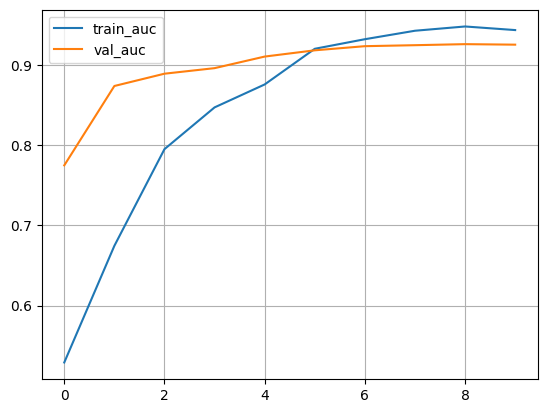

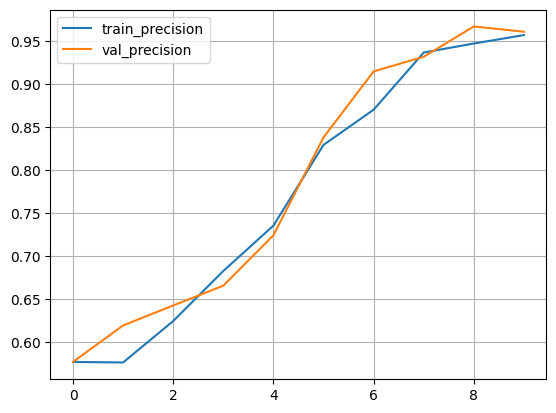

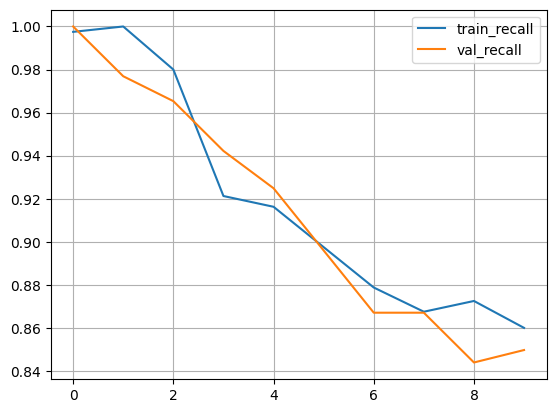

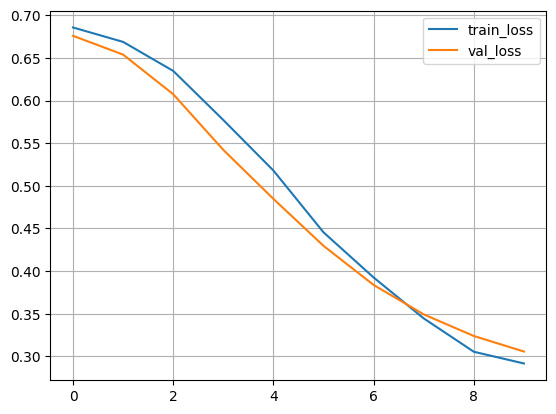

------------------------------------
Threshold evaluation...
------------------------------------
Best threshold on VAL: {'thr': 0.6, 'precision': 1.0, 'recall': 0.8323699421965318, 'f1': 0.9085173501577287}
------------------------------------
Testing...
------------------------------------
TEST metrics: {'loss': 0.34206101298332214, 'auc': 0.9097216129302979, 'precision': 0.9844961166381836, 'recall': 0.8193548321723938}
TEST ROC-AUC: 0.9096332302253645
TEST PR-AUC : 0.9437139848821934

Chosen threshold: 0.6
[[146   0]
 [ 31 124]]
              precision    recall  f1-score   support

           0      0.825     1.000     0.904       146
           1      1.000     0.800     0.889       155

    accuracy                          0.897       301
   macro avg      0.912     0.900     0.896       301
weighted avg      0.915     0.897     0.896       301

TEST Precision: 1.0
TEST Recall   : 0.8
TEST F1       : 0.8888888888888888


In [3]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

EMBED_DIM = 64
MAX_TOKENS = 20000


embed = layers.Embedding(MAX_TOKENS, EMBED_DIM, mask_zero=True)
pool  = layers.GlobalAveragePooling1D()

model = tf.keras.Sequential([
    vectorize,
    embed,
    pool,
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ]
)


_ = model(tf.constant(["dummy text"]))
model.summary()


print('------------------------------------')
print('Training...')
print('------------------------------------')


callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max", patience=2, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc", mode="max", factor=0.5, patience=1, min_lr=1e-6
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)


# --- PLOTS ---
plt.figure()
plt.plot(history.history["auc"], label="train_auc")
plt.plot(history.history["val_auc"], label="val_auc")
plt.legend(); plt.grid(True); plt.show()

plt.figure()
plt.plot(history.history["precision"], label="train_precision")
plt.plot(history.history["val_precision"], label="val_precision")
plt.legend(); plt.grid(True); plt.show()

plt.figure()
plt.plot(history.history["recall"], label="train_recall")
plt.plot(history.history["val_recall"], label="val_recall")
plt.legend(); plt.grid(True); plt.show()

plt.figure()
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend(); plt.grid(True); plt.show()


print('------------------------------------')
print('Threshold evaluation...')
print('------------------------------------')

# 1) Probabilità su VAL
val_probs = model.predict(val_ds, verbose=0).ravel()

# 2) sweep soglie
thresholds = np.linspace(0.05, 0.95, 19)
best = None

for t in thresholds:
    val_pred = (val_probs >= t).astype(int)
    p = precision_score(y_val, val_pred, zero_division=0)
    r = recall_score(y_val, val_pred, zero_division=0)
    f1 = f1_score(y_val, val_pred, zero_division=0)
    if best is None or f1 > best["f1"]:
        best = {"thr": float(t), "precision": p, "recall": r, "f1": f1}

print("Best threshold on VAL:", best)
best_thr = round(best["thr"], 2)



print('------------------------------------')
print('Testing...')
print('------------------------------------')


test_metrics = model.evaluate(test_ds, verbose=0, return_dict=True)
print("TEST metrics:",test_metrics)

test_probs_shallow = model.predict(test_ds, verbose=0).ravel()
print("TEST ROC-AUC:", roc_auc_score(y_test, test_probs_shallow))
print("TEST PR-AUC :", average_precision_score(y_test, test_probs_shallow))


test_pred = (test_probs_shallow >= best_thr).astype(int)
print("\nChosen threshold:", best_thr)
print(confusion_matrix(y_test, test_pred))
print(classification_report(y_test, test_pred, digits=3, zero_division=0))
print("TEST Precision:", precision_score(y_test, test_pred))
print("TEST Recall   :", recall_score(y_test, test_pred))
print("TEST F1       :", f1_score(y_test, test_pred))


------
## BiLSTM

Model: "bilstm_defer"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 text_vectorization (TextVe  (None, 200)               0         
 ctorization)                                                    
                                                                 
 token_embedding (Embedding  (None, 200, 64)           1280000   
 )                                                               
                                                                 
 bilstm (Bidirectional)      (None, 128)               66048     
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense (Dense)               (None, 64)                8256      
                                                                 
 dropout_1 (Dropout)         (None, 64)               

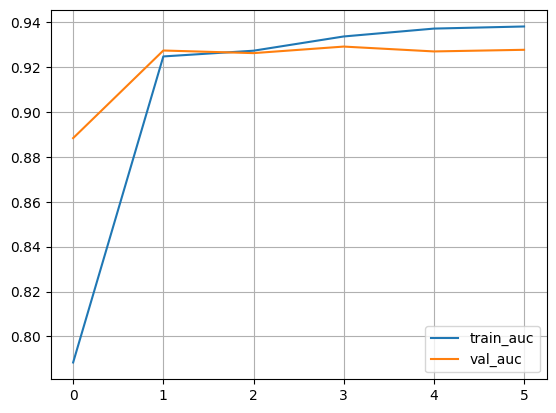

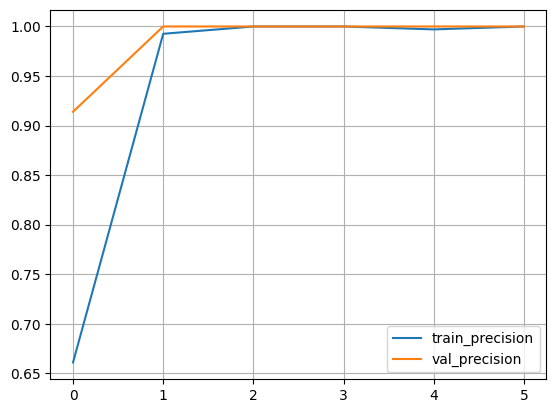

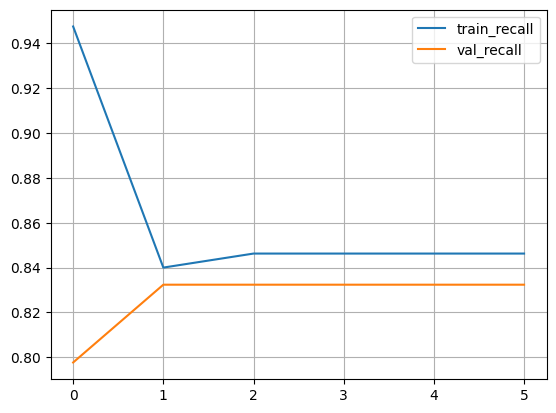

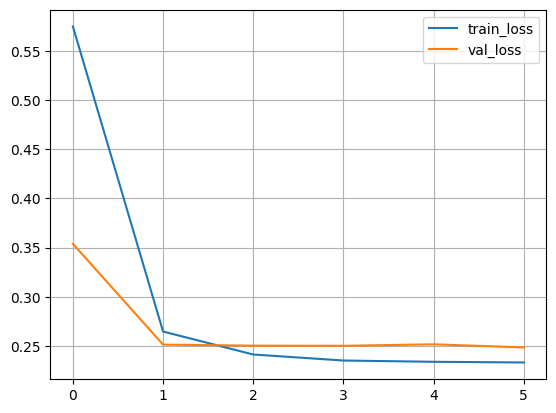

------------------------------------
Threshold evaluation...
------------------------------------
Best threshold on VAL: {'thr': 0.25, 'precision': 1.0, 'recall': 0.8323699421965318, 'f1': 0.9085173501577287}
------------------------------------
Testing...
------------------------------------
TEST metrics: {'loss': 0.2655939757823944, 'auc': 0.9208572506904602, 'precision': 1.0, 'recall': 0.8064516186714172}
TEST ROC-AUC: 0.919840919133893
TEST PR-AUC : 0.9502505742563199

Chosen threshold: 0.25
[[146   0]
 [ 30 125]]
              precision    recall  f1-score   support

           0      0.830     1.000     0.907       146
           1      1.000     0.806     0.893       155

    accuracy                          0.900       301
   macro avg      0.915     0.903     0.900       301
weighted avg      0.917     0.900     0.900       301

TEST Precision: 1.0
TEST Recall   : 0.8064516129032258
TEST F1       : 0.8928571428571429


In [4]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

EMBED_DIM = 64
MAX_TOKENS = 20000

embed = layers.Embedding(
    input_dim=MAX_TOKENS,
    output_dim=EMBED_DIM,
    mask_zero=True,
    name="token_embedding"
)

# BiLSTM: produce una rappresentazione "contestualizzata" della sequenza
# - return_sequences=False -> restituisce solo l'ultimo stato (summary della sequenza)
bilstm = layers.Bidirectional(
    layers.LSTM(64, return_sequences=False),
    name="bilstm"
)

model = tf.keras.Sequential([
    vectorize,           # (batch,) string -> (batch, T) int
    embed,               # (batch, T) -> (batch, T, E)
    bilstm,              # (batch, T, E) -> (batch, 128) (64*2 perché bidirezionale)
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),
], name="bilstm_defer")

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ]
)

_ = model(tf.constant(["dummy text"]))
model.summary()


print('------------------------------------')
print('Training...')
print('------------------------------------')

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max", patience=2, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc", mode="max", factor=0.5, patience=1, min_lr=1e-6
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)



# --- PLOTS ---
plt.figure()
plt.plot(history.history["auc"], label="train_auc")
plt.plot(history.history["val_auc"], label="val_auc")
plt.legend(); plt.grid(True); plt.show()

plt.figure()
plt.plot(history.history["precision"], label="train_precision")
plt.plot(history.history["val_precision"], label="val_precision")
plt.legend(); plt.grid(True); plt.show()

plt.figure()
plt.plot(history.history["recall"], label="train_recall")
plt.plot(history.history["val_recall"], label="val_recall")
plt.legend(); plt.grid(True); plt.show()

plt.figure()
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend(); plt.grid(True); plt.show()


print('------------------------------------')
print('Threshold evaluation...')
print('------------------------------------')

# 1) Probabilità su VAL
val_probs = model.predict(val_ds, verbose=0).ravel()

# 2) sweep soglie
thresholds = np.linspace(0.05, 0.95, 19)
best = None

for t in thresholds:
    val_pred = (val_probs >= t).astype(int)
    p = precision_score(y_val, val_pred, zero_division=0)
    r = recall_score(y_val, val_pred, zero_division=0)
    f1 = f1_score(y_val, val_pred, zero_division=0)
    if best is None or f1 > best["f1"]:
        best = {"thr": float(t), "precision": p, "recall": r, "f1": f1}

print("Best threshold on VAL:", best)
best_thr = round(best["thr"], 2)



print('------------------------------------')
print('Testing...')
print('------------------------------------')


test_metrics = model.evaluate(test_ds, verbose=0, return_dict=True)
print("TEST metrics:",test_metrics)

test_probs_bilstm = model.predict(test_ds, verbose=0).ravel()
print("TEST ROC-AUC:", roc_auc_score(y_test, test_probs_bilstm))
print("TEST PR-AUC :", average_precision_score(y_test, test_probs_bilstm))


test_pred = (test_probs_bilstm >= best_thr).astype(int)
print("\nChosen threshold:", best_thr)
print(confusion_matrix(y_test, test_pred))
print(classification_report(y_test, test_pred, digits=3, zero_division=0))
print("TEST Precision:", precision_score(y_test, test_pred))
print("TEST Recall   :", recall_score(y_test, test_pred))
print("TEST F1       :", f1_score(y_test, test_pred))

________
## DistilBERT Transfer Learning - Staged fine-tuning

In [6]:

!pip -q install -U "transformers>=4.41,<4.43" "accelerate>=0.30" "tokenizers>=0.19,<0.21" "huggingface_hub>=0.33.5" "safetensors>=0.4.3"
import transformers, huggingface_hub, tokenizers, accelerate
print("transformers:", transformers.__version__)
print("huggingface_hub:", huggingface_hub.__version__)
print("tokenizers:", tokenizers.__version__)
print("accelerate:", accelerate.__version__)

from transformers import AutoTokenizer, TFDistilBertModel, TFAutoModel
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score
)
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

tok = AutoTokenizer.from_pretrained("distilbert-base-uncased")
enc = TFAutoModel.from_pretrained("distilbert-base-uncased")
print("OK:", tok.__class__.__name__, enc.__class__.__name__)

transformers: 4.42.4
huggingface_hub: 0.36.2
tokenizers: 0.19.1
accelerate: 1.12.0


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_projector.bias', 'vocab_layer_norm.weight', 'vocab_transform.bias', 'vocab_layer_norm.bias', 'vocab_transform.weight']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


OK: DistilBertTokenizerFast TFDistilBertModel


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_projector.bias', 'vocab_layer_norm.weight', 'vocab_transform.bias', 'vocab_layer_norm.bias', 'vocab_transform.weight']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, 256)]                0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, 256)]                0         []                            
 )                                                                                                
                                                                                                  
 tf_distil_bert_model (TFDi  TFBaseModelOutput(last_hid   6636288   ['input_ids[0][0]',           
 stilBertModel)              den_state=(None, 256, 768)   0          'attention_mask[0][0]']      
                             , hidden_states=None, atte                                       

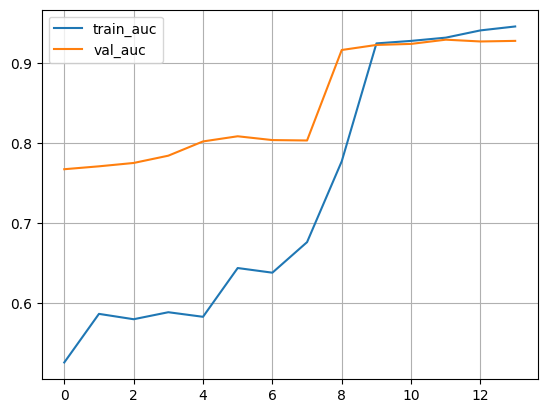

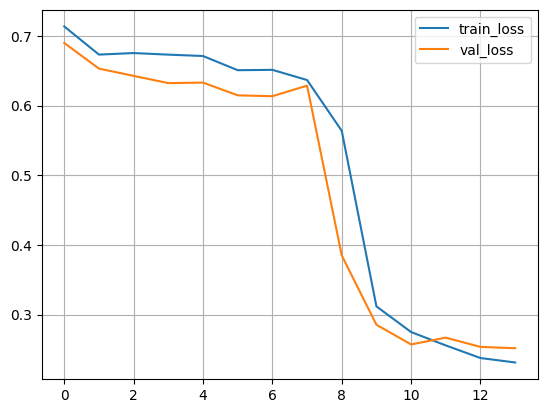

------------------------------------
Threshold evaluation...
------------------------------------
Best threshold on VAL: {'thr': 0.25, 'precision': 0.9931506849315068, 'recall': 0.838150289017341, 'f1': 0.9090909090909091}  -> using: 0.25
------------------------------------
Testing...
------------------------------------
TEST metrics (Keras @thr=0.5): {'loss': 0.2638292908668518, 'auc': 0.9367432594299316, 'precision': 1.0, 'recall': 0.8064516186714172}
TEST ROC-AUC: 0.9365444100751215
TEST PR-AUC : 0.9589674187720558

Chosen threshold: 0.25
[[144   2]
 [ 28 127]]
              precision    recall  f1-score   support

           0      0.837     0.986     0.906       146
           1      0.984     0.819     0.894       155

    accuracy                          0.900       301
   macro avg      0.911     0.903     0.900       301
weighted avg      0.913     0.900     0.900       301

TEST Precision: 0.9844961240310077
TEST Recall   : 0.8193548387096774
TEST F1       : 0.8943661971830

In [7]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 256
BATCH_SIZE = 16

# ----------------------------
# 1) Tokenizer + encoding
# ----------------------------
tok = AutoTokenizer.from_pretrained(MODEL_NAME)

def encode_texts(texts, max_len=MAX_LEN):
    enc = tok(
        list(map(str, texts)),
        truncation=True,
        padding="max_length",
        max_length=max_len,
        return_tensors="tf"
    )
    return {
        "input_ids": enc["input_ids"],
        "attention_mask": enc["attention_mask"],
    }

train_enc = encode_texts(X_train)
val_enc   = encode_texts(X_val)
test_enc  = encode_texts(X_test)

# ----------------------------
# 2) tf.data datasets
# ----------------------------
train_ds_bert = tf.data.Dataset.from_tensor_slices((train_enc, y_train))
train_ds_bert = train_ds_bert.shuffle(len(y_train), seed=42, reshuffle_each_iteration=True)
train_ds_bert = train_ds_bert.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds_bert = tf.data.Dataset.from_tensor_slices((val_enc, y_val)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds_bert = tf.data.Dataset.from_tensor_slices((test_enc, y_test)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# ----------------------------
# 3) Build model: DistilBERT + head
# ----------------------------
bert = TFDistilBertModel.from_pretrained(MODEL_NAME)

input_ids = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32, name="input_ids")
attention_mask = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32, name="attention_mask")

outputs = bert(input_ids=input_ids, attention_mask=attention_mask)
cls_token = outputs.last_hidden_state[:, 0, :]  # (batch, 768)

# head (trainable)
x = tf.keras.layers.Dropout(0.3)(cls_token)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.3)(x)
out = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(
    inputs={"input_ids": input_ids, "attention_mask": attention_mask},
    outputs=out
)

# build (prende un batch vero dal dataset)
for xb, yb in train_ds_bert.take(1):
    _ = model(xb)

model.summary()

# ----------------------------
# Helper: compile + callbacks
# ----------------------------
def compile_model(lr: float):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ]
    )

def make_callbacks():
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_auc", mode="max", patience=2, restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_auc", mode="max", factor=0.5, patience=1, min_lr=1e-6
        )
    ]

# ----------------------------
# 4) STAGE A — encoder frozen
# ----------------------------
print("\n==============================")
print("STAGE A: Frozen encoder (train head only)")
print("==============================")

bert.trainable = False  # freeze everything
compile_model(lr=3e-4) 

history_a = model.fit(
    train_ds_bert,
    validation_data=val_ds_bert,
    epochs=10,
    callbacks=make_callbacks(),
    verbose=1
)

# ----------------------------
# 5) STAGE B — partial unfreeze
# ----------------------------
print("\n==============================")
print("STAGE B: Partial unfreeze (last N transformer blocks)")
print("==============================")

N_UNFREEZE = 2
FREEZE_LAYERNORM = False 

bert.trainable = True 
for layer in bert.distilbert.transformer.layer:
    layer.trainable = False

for layer in bert.distilbert.transformer.layer[-N_UNFREEZE:]:
    layer.trainable = True

# freeza LayerNorm in unblocked blocks
if FREEZE_LAYERNORM:
    for layer in bert.distilbert.transformer.layer[-N_UNFREEZE:]:
        for sub in layer.submodules:
            if "layer_norm" in sub.name:
                sub.trainable = False

# lower LR
compile_model(lr=1e-5)

history_b = model.fit(
    train_ds_bert,
    validation_data=val_ds_bert,
    epochs=10,
    callbacks=make_callbacks(),
    verbose=1
)

# ----------------------------
# 6) Plotting
# ----------------------------
def concat_hist(key):
    return history_a.history.get(key, []) + history_b.history.get(key, [])

plt.figure()
plt.plot(concat_hist("auc"), label="train_auc")
plt.plot(concat_hist("val_auc"), label="val_auc")
plt.legend(); plt.grid(True); plt.show()

plt.figure()
plt.plot(concat_hist("loss"), label="train_loss")
plt.plot(concat_hist("val_loss"), label="val_loss")
plt.legend(); plt.grid(True); plt.show()

# ----------------------------
# 7) Threshold selection on VAL 
# ----------------------------
print('------------------------------------')
print('Threshold evaluation...')
print('------------------------------------')

val_probs = model.predict(val_ds_bert, verbose=0).ravel()

thresholds = np.linspace(0.05, 0.95, 19)
best = None
for t in thresholds:
    val_pred = (val_probs >= t).astype(int)
    p = precision_score(y_val, val_pred, zero_division=0)
    r = recall_score(y_val, val_pred, zero_division=0)
    f1 = f1_score(y_val, val_pred, zero_division=0)
    if best is None or f1 > best["f1"]: ## use F1 to maximize
        best = {"thr": float(t), "precision": p, "recall": r, "f1": f1}

best_thr = round(best["thr"], 2)
print("Best threshold on VAL:", best, " -> using:", best_thr)

# ----------------------------
# 8) Test evaluation
# ----------------------------
print('------------------------------------')
print('Testing...')
print('------------------------------------')

test_metrics = model.evaluate(test_ds_bert, verbose=0, return_dict=True)
print("TEST metrics (Keras @thr=0.5):", test_metrics)

test_probs_bert = model.predict(test_ds_bert, verbose=0).ravel()
print("TEST ROC-AUC:", roc_auc_score(y_test, test_probs_bert))
print("TEST PR-AUC :", average_precision_score(y_test, test_probs_bert))

test_pred = (test_probs_bert >= best_thr).astype(int)

print("\nChosen threshold:", best_thr)
print(confusion_matrix(y_test, test_pred))
print(classification_report(y_test, test_pred, digits=3, zero_division=0))
print("TEST Precision:", precision_score(y_test, test_pred, zero_division=0))
print("TEST Recall   :", recall_score(y_test, test_pred, zero_division=0))
print("TEST F1       :", f1_score(y_test, test_pred, zero_division=0))

_________
## Final evaluation

<Figure size 640x480 with 0 Axes>

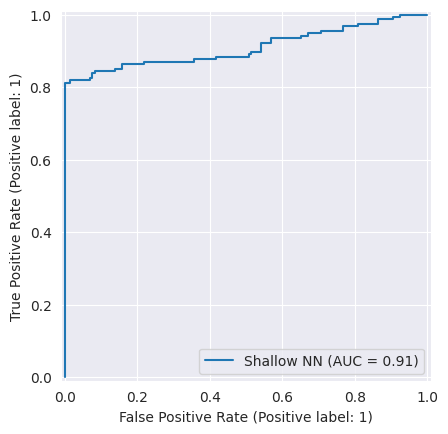

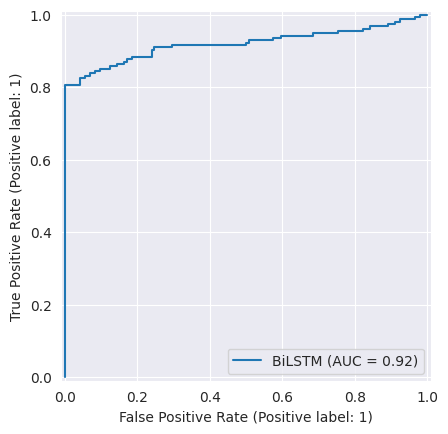

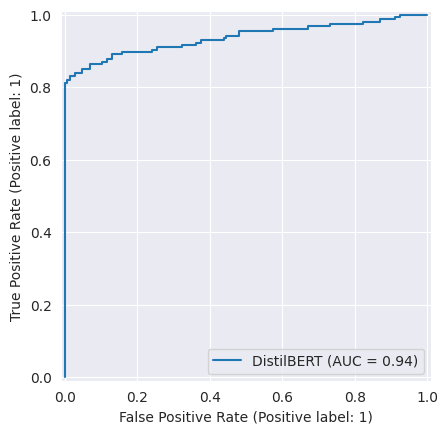

In [13]:
from sklearn.metrics import RocCurveDisplay
import seaborn as sns

plt.figure()
sns.set_style('darkgrid')


RocCurveDisplay.from_predictions(y_test, test_probs_shallow, name="Shallow NN")
RocCurveDisplay.from_predictions(y_test, test_probs_bilstm, name="BiLSTM")
RocCurveDisplay.from_predictions(y_test, test_probs_bert, name="DistilBERT")

plt.show()